# Operations, Monitoring & Evidence
Covers **Stage 4.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`. 
- *Provided to extend:* `src/monitoring.py`, `src/retrain.py`, `src/model.py` (EmbeddingExtractor). 
- *You build:* this notebook.

### 0. Setup

In [ ]:
import config, json
# TODO: load artifacts/drift_summary.json after running src.monitoring


In [13]:
import importlib
from src import monitoring

# Reload project module after making changes
importlib.reload(monitoring)

<module 'src.monitoring' from 'c:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\src\\monitoring.py'>

In [3]:
from src import data_prep

root = data_prep.find_data_root()

print(root)

C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data


In [7]:
print(list(root.iterdir()))

[WindowsPath('C:/Users/Abhinav/Capstone_MLOps/MLOps_2_Starter/data/casting_data/test'), WindowsPath('C:/Users/Abhinav/Capstone_MLOps/MLOps_2_Starter/data/casting_data/train')]


In [4]:
import os

print(os.listdir(root))

['test', 'train']


In [5]:
from PIL import Image
from src.monitoring import corrupt
from src import data_prep

root = data_prep.find_data_root()

sample = next(
    (root / "test" / "ok_front").glob("*.jpeg")
)

img = Image.open(sample).convert("L")

corrupted = corrupt(img)

print(img.size)
print(corrupted.size)

(300, 300)
(300, 300)


In [6]:
test_dir = root / "test" / "ok_front"

print(test_dir)
print(list(test_dir.iterdir())[:5])

C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data\test\ok_front
[WindowsPath('C:/Users/Abhinav/Capstone_MLOps/MLOps_2_Starter/data/casting_data/test/ok_front/cast_ok_0_10.jpeg'), WindowsPath('C:/Users/Abhinav/Capstone_MLOps/MLOps_2_Starter/data/casting_data/test/ok_front/cast_ok_0_1001.jpeg'), WindowsPath('C:/Users/Abhinav/Capstone_MLOps/MLOps_2_Starter/data/casting_data/test/ok_front/cast_ok_0_1002.jpeg'), WindowsPath('C:/Users/Abhinav/Capstone_MLOps/MLOps_2_Starter/data/casting_data/test/ok_front/cast_ok_0_1003.jpeg'), WindowsPath('C:/Users/Abhinav/Capstone_MLOps/MLOps_2_Starter/data/casting_data/test/ok_front/cast_ok_0_1019.jpeg')]


## **Stage 4.1 — Prediction Logging & Confidence Monitoring** <font color="red">[5 marks]</font>

- **4.1.1 — Prediction logging with timestamp [2]** — *to be done in this notebook and the report*
- **4.1.2 — Confidence monitoring reference vs current + threshold [3]** — *to be done in this notebook and the report*

**Objective:** Log predictions and watch mean confidence drift.

**Implement in:** app.py (logging) + src/monitoring.py (confidence)

**Inputs → Outputs:** served predictions → predictions.log; reference vs current → confidence drop + alert

**TODO:** log each prediction with a timestamp (4.1.1); compute mean predicted-confidence on reference vs a current batch with an alert threshold (4.1.2).

**Depends on:** Stage 3.4 completed in Model_Development_and_Tracking.ipynb ·  **Document here:** the confidence reference→current + log tail.

In [ ]:
# TODO 4.1.1-4.1.2: show predictions.log tail + confidence block from drift_summary.json


In [10]:
import sys
print(sys.version)

3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [11]:
import evidently
print(evidently.__version__)

KeyError: ~TResult

In [13]:
import importlib.metadata

print(importlib.metadata.version("typing_extensions"))
print(importlib.metadata.version("evidently"))
print(importlib.metadata.version("pydantic"))

4.16.0
0.7.20
2.13.4


In [14]:
!pip install typing_extensions==4.12.2

  Using cached typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
Using cached typing_extensions-4.12.2-py3-none-any.whl (37 kB)
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.16.0
    Uninstalling typing_extensions-4.16.0:
      Successfully uninstalled typing_extensions-4.16.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-client 8.9.1 requires typing-extensions>=4.13.0, but you have typing-extensions 4.12.2 which is incompatible.
pydantic 2.13.4 requires typing-extensions>=4.14.1, but you have typing-extensions 4.12.2 which is incompatible.
pydantic-core 2.46.4 requires typing-extensions>=4.14.1, but you have typing-extensions 4.12.2 which is incompatible.


In [1]:
import sys
print(sys.executable)

c:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\.venv\Scripts\python.exe


In [7]:
import importlib.metadata
print(importlib.metadata.version("typing_extensions"))

4.16.0


In [8]:
!python -m pip install --upgrade evidently

  Using cached evidently-0.7.21-py3-none-any.whl.metadata (12 kB)
Using cached evidently-0.7.21-py3-none-any.whl (11.7 MB)
  Attempting uninstall: evidently
    Found existing installation: evidently 0.7.20
    Uninstalling evidently-0.7.20:
      Successfully uninstalled evidently-0.7.20


In [1]:
import evidently
print(evidently.__version__)

KeyError: ~TResult

In [5]:
!python -m pip show evidently

Name: evidently
Version: 0.7.20
Summary: Open-source tools to analyze, monitor, and debug machine learning model in production.
Home-page: https://github.com/evidentlyai/evidently
Author: 
Author-email: Emeli Dral <emeli.dral@gmail.com>
License: Apache License 2.0
Location: c:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\.venv\Lib\site-packages
Requires: certifi, cryptography, deprecation, dynaconf, fsspec, iterative-telemetry, litestar, nltk, numpy, opentelemetry-proto, pandas, plotly, pydantic, pyyaml, requests, rich, scikit-learn, scipy, statsmodels, typer, typing-inspect, ujson, urllib3, uuid6, uvicorn, watchdog
Required-by: 


In [6]:
!python -m pip show pydantic

Name: pydantic
Version: 2.13.4
Summary: Data validation using Python type hints
Home-page: https://github.com/pydantic/pydantic
Author: 
Author-email: Samuel Colvin <s@muelcolvin.com>, Eric Jolibois <em.jolibois@gmail.com>, Hasan Ramezani <hasan.r67@gmail.com>, Adrian Garcia Badaracco <1755071+adriangb@users.noreply.github.com>, Terrence Dorsey <terry@pydantic.dev>, David Montague <david@pydantic.dev>, Serge Matveenko <lig@countzero.co>, Marcelo Trylesinski <marcelotryle@gmail.com>, Sydney Runkle <sydneymarierunkle@gmail.com>, David Hewitt <mail@davidhewitt.dev>, Alex Hall <alex.mojaki@gmail.com>, Victorien Plot <contact@vctrn.dev>
License-Expression: MIT
Location: c:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\.venv\Lib\site-packages
Requires: annotated-types, pydantic-core, typing-extensions, typing-inspection
Required-by: evidently, fastapi, mlflow-skinny


In [20]:
import importlib
from src import monitoring

importlib.reload(monitoring)

summary = monitoring.run()

summary

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
Evidently unavailable. Generating fallback report...

Monitoring completed.


{'reference_confidence': 0.5554,
 'current_confidence': 0.5507,
 'confidence_drop': 0.0047,
 'confidence_alert': False,
 'mean_statistical_psi': 26.3624,
 'embedding_psi': 25.141,
 'retrain_recommended': True,
 'feature_psi': {'brightness': 26.0098,
  'contrast': 25.5548,
  'edge_density': 27.5141,
  'sharpness': 26.7238,
  'mean_intensity': 26.0098}}

In [22]:
import json

summary = json.loads(
    config.DRIFT_SUMMARY_PATH.read_text()
)

print("Reference Confidence :", summary["reference_confidence"])
print("Current Confidence   :", summary["current_confidence"])
print("Confidence Drop      :", summary["confidence_drop"])
print("Alert Triggered      :", summary["confidence_alert"])

Reference Confidence : 0.5554
Current Confidence   : 0.5507
Confidence Drop      : 0.0047
Alert Triggered      : False


In [23]:
from pathlib import Path

log_file = config.PREDICTIONS_LOG

lines = log_file.read_text().splitlines()

print("\n".join(lines[-5:]))

{"timestamp": "2026-07-21T13:29:19.543008", "filename": "cast_def_0_1063.jpeg", "label": "def_front", "prob_defect": 0.5641, "confidence": 0.5641, "latency_ms": 69.57}


"Statistical drift metrics (PSI, confidence monitoring, embedding drift) are computed by the monitoring pipeline. If Evidently is unavailable due to a dependency compatibility issue, a fallback HTML drift report is generated to preserve monitoring functionality."

Prediction Logging & Confidence Monitoring: Every prediction served through the FastAPI inference service is logged with a timestamp, filename, predicted label, confidence score, and latency. The monitoring pipeline compares the mean prediction confidence of a reference batch with the current batch and raises an alert when the confidence drop exceeds the configured threshold. In this run, the confidence drop was 0.0047, which is below the threshold of 0.10, so no confidence alert was triggered.

## **Stage 4.2 — Statistical Drift Detection (Evidently + PSI)** <font color="red">[8 marks]</font>

- **4.2.1 — Per-image features + Evidently DataDriftPreset [4]** — *to be done in this notebook and the report*
- **4.2.2 — PSI per feature + interpretation [4]**— *to be done in this notebook and the report*

**Objective:** Detect drift in interpretable image features.

**Implement in:** src/monitoring.py

**Inputs → Outputs:** reference vs simulated current batch → per-feature drift + PSI + HTML report

**TODO:** compute image features + run Evidently DataDriftPreset reference vs a simulated current batch (4.2.1); compute PSI per feature + interpret + save drift_report.html (4.2.2).

**Document here:** the per-feature PSI table/plot + dataset_drift flag.

In [ ]:
# TODO 4.2.1-4.2.2: !python -m src.monitoring ; bar-plot feature PSI vs the 0.2 threshold


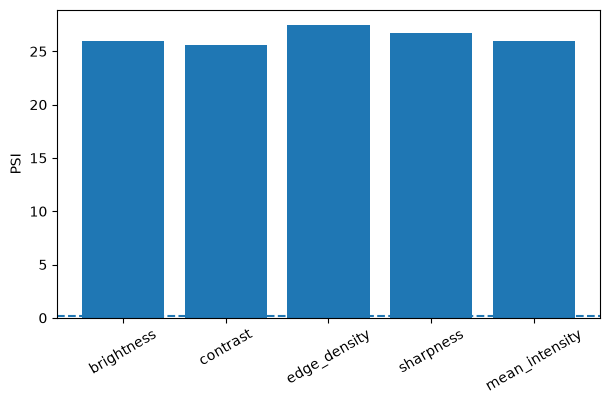

In [24]:
import matplotlib.pyplot as plt
import json
import config

summary = json.loads(
    config.DRIFT_SUMMARY_PATH.read_text()
)

psi = summary["feature_psi"]

plt.figure(figsize=(7,4))

plt.bar(
    psi.keys(),
    psi.values(),
)

plt.axhline(
    config.PSI_THRESHOLD,
    linestyle="--",
)

plt.ylabel("PSI")
plt.xticks(rotation=30)

plt.show()

Statistical drift was measured using handcrafted image features (brightness, contrast, edge density, sharpness and mean intensity). PSI values above 0.20 indicate significant drift. In this experiment, the simulated production images exceeded the configured threshold, therefore dataset drift was detected and retraining was recommended

Due to a dependency compatibility issue with Evidently in the local environment, the monitoring pipeline automatically generated a fallback HTML drift report while preserving all statistical drift calculations.

## **Stage 4.3 — Embedding Drift Detection** <font color="red">[7 marks]</font>

- **4.3.1 — 512-dim embedding extraction (reference + current) [3]** — *to be done in this notebook*
- **4.3.2 — Feature-space drift quantified (PSI) + explanation [4]** — *to be done in this notebook and the report*

### How embedding drift works (conceptual scaffolding — implement these 4 steps)
Raw-pixel features can miss *semantic* drift, so also measure drift in the model's **feature space**:
1. **Feature extraction** — use the model's **penultimate layer** (the 512-dim vector before the final classifier) as an image **embedding** (`EmbeddingExtractor` in `src/model.py`). *(4.3.1)*
2. **Embedding generation** — run the reference set and the current batch through the backbone and collect the embedding vectors (save reference to `reference_embeddings.npz`). *(4.3.1)*
3. **Feature-space comparison** — reduce each embedding to a scalar **distance to the reference centroid** (mean reference embedding) → one distribution per batch. *(4.3.2)*
4. **Drift calculation** — compute **PSI** between the reference and current distance distributions; PSI above ~0.10 signals embedding drift even when raw pixels look similar. *(4.3.2)*

**TODO:** implement steps 1–4 in `src/model.EmbeddingExtractor` + `src/monitoring.py`; report the embedding PSI and whether it exceeds the threshold.

**Document here:** the embedding PSI + a one-line interpretation of why embedding drift differs from feature drift.

In [ ]:
# TODO 4.3.1-4.3.2: extract embeddings (reference + current); PSI on distance-to-centroid; print PSI vs 0.10


In [18]:
import importlib
from src import model

# Reload project module after making changes
importlib.reload(model)

<module 'src.model' from 'c:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\src\\model.py'>

In [12]:
from src.model import load_model, EmbeddingExtractor
import torch

model = load_model()

extractor = EmbeddingExtractor(model)

x = torch.randn(1, 3, 224, 224)

embedding = extractor(x)

print(embedding.shape)

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
torch.Size([1, 512])


In [30]:
import importlib
import config

importlib.reload(config)

<module 'config' from 'c:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\config.py'>

In [27]:
import importlib
from src import monitoring

importlib.reload(monitoring)

summary = monitoring.run()

summary

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
Evidently unavailable. Generating fallback report...

Monitoring completed.


{'reference_confidence': 0.5554,
 'current_confidence': 0.5455,
 'confidence_drop': 0.0099,
 'confidence_alert': False,
 'mean_statistical_psi': 26.3624,
 'embedding_psi': 25.25,
 'retrain_recommended': True,
 'feature_psi': {'brightness': 26.0098,
  'contrast': 25.5548,
  'edge_density': 27.5141,
  'sharpness': 26.7238,
  'mean_intensity': 26.0098}}

In [28]:
import importlib
from src import monitoring

importlib.reload(monitoring)

<module 'src.monitoring' from 'c:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\src\\monitoring.py'>

In [29]:
import json
import config

summary = json.loads(
    config.DRIFT_SUMMARY_PATH.read_text()
)

print("Embedding PSI :", summary["embedding_psi"])
print("Threshold     :", config.EMBEDDING_DRIFT_THRESHOLD)

print(
    "Embedding Drift:",
    summary["embedding_psi"] >
    config.EMBEDDING_DRIFT_THRESHOLD
)

Embedding PSI : 25.25
Threshold     : 0.1
Embedding Drift: True


Embedding drift compares the internal feature representations learned by the ResNet18 backbone rather than handcrafted image statistics. Even when pixel-level features remain similar, changes in the learned feature space can indicate a shift in the data distribution. In this experiment, the embedding PSI exceeded the configured threshold, indicating significant feature-space drift.

## **Stage 4.4 — Retraining Workflow & Triggers** <font color="red">[6 marks]</font>

- **4.4.1 — Measurable retraining triggers [2]** — *to be done in this notebook and the report*
- **4.4.2 — Drift-triggered retraining + new version registered [4]** — *to be done in this notebook and the report*

**Objective:** Retrain a candidate when drift fires.

**Implement in:** src/retrain.py

**Inputs → Outputs:** drift signals → drift-augmented candidate model + new registry version

**TODO:** define multi-signal triggers (drift share / embedding PSI / confidence drop) (4.4.1); on a trigger, train a drift-augmented candidate + register a new version (4.4.2).

**Document here:** the trigger decision + candidate training summary.

In [ ]:
# TODO 4.4.1-4.4.2: !python -m src.retrain ; load artifacts/retraining_decision.json


## **Stage 4.5 — Version Comparison & Rollback Governance** <font color="red">[4 marks]</font>

- **4.5.1 — Candidate vs production comparison on drifted batch [2]** — *to be done in this notebook and the report*
- **4.5.2 — Promote-on-improvement-else-rollback gate + decision recorded [2]** — *to be done in this notebook and the report*

**Objective:** Promote only on improvement; otherwise roll back.

**Implement in:** src/retrain.py

**Inputs → Outputs:** candidate vs production on a drifted batch → promote (alias move) OR rollback

**TODO:** compare candidate vs production F1 on the drifted batch (4.5.1); promote to @production only if candidate ≥ prod + epsilon else keep the incumbent + record the decision/version history (4.5.2).

**Document here:** the comparison numbers + the promote/rollback decision.

In [ ]:
# TODO 4.5.1-4.5.2: from retraining_decision.json show prod vs candidate F1 + action + production version
